# 90819-Python Final Project: Effect of Proximity to Polluters on Home Values and Vacancy Rates
Pittsburgh consistently ranks as one of the worst polluted areas in the United States. Allegheny county in particular, ranks as one of the worst, ranking 23 in the US in 2026 (https://www.lung.org/research/sota/key-findings/most-polluted-places). Industrial polluters can cause major adverse health effects due to the release of harmful particles into the air, such as benzene, lead and lead compounds, mercury and mercury compounds, methanol, and nitrates. We want to see if proximity to industrial polluters have any affect on where people choose to live. We proxy this by home values and vacancy rates.

Our primary research question is as follows: 
#### *How does proximity to major industrial polluters shape home values, vacancy, and housing distress in Mon Valley municipalities, compared with the rest of Allegheny County?*

## Analysis Organization
We organize our analysis into the following key sections:
1. Data Processing
    - Housing and demographic data sources: The US ACS 2020-2024 5-year survey data at the census tract level, and Allegheny County Property Assessments data at the parcel level, and Allegheny County municipalities boundaries.
    - Pollution data: EPA Toxic Release Inventory (TRI) data, and EPA Risk Screening Environmental Indicators (RSEI) data. 
    - Exploratory data analysis: Bar charts, histograms, density plots, and maps exploring the data for trends.
3. Regression Analysis
    - Modeling the effect of proximity to industrial polluters on property sale prices for residential properties. 
    - Modeling the effect proximity of industrial polluters on vacancy rates. 
    - Each model includes an OLS regression and a logit regression for properties located in Mon Valley.
4. Conclusions, Limitations, and Areas for Further Study

### Import Libraries and Load Libraries

In [90]:
# note, you may need to install these libraries first
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pytidycensus as tc
# import mapclassify as mc
from pathlib import Path
from patsy import dmatrices
#from sklearn.linear_model import LinearRegression
import pyfixest as pf
import statsmodels.api as sm
from pathlib import Path

## 1. Data processing
The data processing for this analysis requires running scripts 01-03, which handle the loading, cleaning, and merging of the various datasets used in the study. In this document, we provide an overview of the steps involved and the structure of the resulting datasets, but the full processing code is contained within those scripts. The output of these scripts is a cleaned and merged dataset ready for analysis, which, due to size constraints, are stored on Google Drive.

The dataframe after all of the data are cleaned and merged contains 585,005 rows and 52 columns. This main dataframe is too large to add to github (over 1 gb). The data can be shared via google drive. The exploratory analysis is still below. 

The subset used for final analysis and regression contains 24,139 rows and 52 columns. The regressions will be run on this final dataset.

## 1.1. Housing and Demographic Data

The housing and demographic data includes information from the US ACS 2020-2024 5-year survey at the census tract level, Allegheny County Property Assessments data at the parcel level, and Allegheny County municipalities boundaries. We use this data to understand the local distribution of population and demographic characteristics, housing stock, and property values, which we then use to analyze the effect of proximity to industrial polluters on home values and vacancy rates.

The code below demonstrates how we loaded, cleaned, and merged the housing and demographic data for our analysis. The full code used to produce these datasets is available in script `01_parcel_analysis.ipynb` and `acs_pull_code.ipynb`.

In [ ]:
output_dir = Path(r"")
# load full dataframe
property_gdf = gpd.read_file(output_dir / "90819_analysis_data_full.geojson")

# load final analysis dataset 
analysis_gdf = gpd.read_file(output_dir / "90819_analysis_data.geojson")

In [36]:
# create dummy variable for Mon Valley Municipalities
monvalley_municipalities = [
    "FORWARD",
    "ELIZABETH",
    "WEST ELIZABETH",
    "JEFFERSON HILLS",
    "CLAIRTON",
    "LINCOLN",
    "LIBERTY",
    "GLASSPORT",
    "PORT VUE",
    "MCKEESPORT",
    "WEST MIFFLIN",
    "DRAVOSBURG",
    "DUQUENSNE",
    "NORTH VERSAILLES",
    "EAST PITTSBURGH",
    "NORTH BRADDOCK",
    "BRADDOCK",
    "WHITAKER",
    "MUNHALL",
    "WEST HOMESTEAD",
    "HOMESTEAD",
    "RANKIN",
    "SWISSVALE"
] 

property_gdf["mon_valley"] = property_gdf["name"].isin(monvalley_municipalities)
analysis_gdf["mon_valley"] = analysis_gdf["name"].isin(monvalley_municipalities)

## 2. Exploratory Analysis
We will start by looking at the property assessor data.

Top 3 parcel uses by class: 
1. RESIDENTIAL (523754)
2. COMMERCIAL (35870)
3. GOVERNMENT (16881)
Top 3 parcel uses by class in 2024: 
1. RESIDENTIAL (24161)
2. COMMERCIAL (1419)
3. INDUSTRIAL (142)


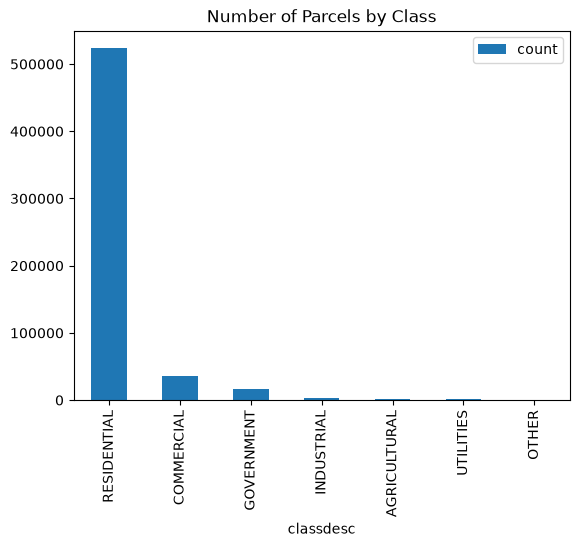

In [41]:
# get number of buildings by class
buildings_by_class = (property_gdf
                      .groupby("classdesc")
                      .size()
                      .reset_index(name="count")
                      .sort_values(by="count", ascending=False)
                      )

buildings_by_class.plot.bar(x="classdesc", y="count", title="Number of Parcels by Class")

print(f"Top 3 parcel uses by class: \n1. {buildings_by_class.iloc[0]['classdesc']} ({buildings_by_class.iloc[0]['count']})\n2. {buildings_by_class.iloc[1]['classdesc']} ({buildings_by_class.iloc[1]['count']})\n3. {buildings_by_class.iloc[2]['classdesc']} ({buildings_by_class.iloc[2]['count']})")

# filter to the year 2024 and check again
assessment_parcel_2024_df = property_gdf[property_gdf["sale_year"]==2024]
buildings_by_class_2024 = (assessment_parcel_2024_df
                           .groupby("classdesc")
                           .size()
                           .reset_index(name="count")
                           .sort_values(by="count", ascending=False))

print(f"Top 3 parcel uses by class in 2024: \n1. {buildings_by_class_2024.iloc[0]['classdesc']} ({buildings_by_class_2024.iloc[0]['count']})\n2. {buildings_by_class_2024.iloc[1]['classdesc']} ({buildings_by_class_2024.iloc[1]['count']})\n3. {buildings_by_class_2024.iloc[2]['classdesc']} ({buildings_by_class_2024.iloc[2]['count']})")
# print("We want to focus on residential properties for this analysis.")

Most parcels are residential, which is perfect for our study because even when we filter to the dataset to just one year, we still get a significant number of residential parcels.

,saleprice
min,0.00
max,14466000.00
mean,220892.47
median,150000.00


<Axes: >

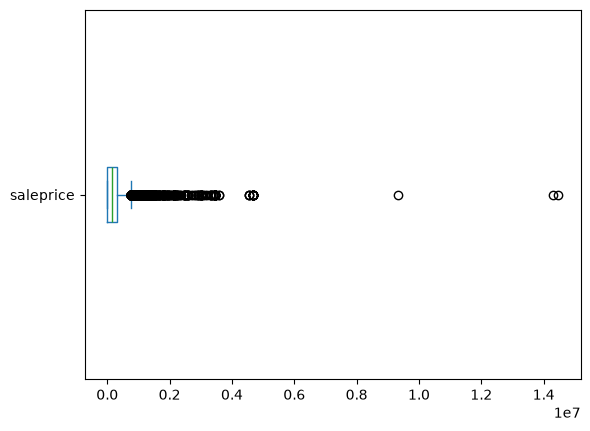

In [42]:
# Median residential sale value in 2024
summary_residential_sale_value_2024 = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                                      .agg({"saleprice":["min","max","mean","median"]})
                                      .round(2)
                                      )
display(summary_residential_sale_value_2024)

assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"].plot.box(vert=False)

# create a boxplot of the residential sale values in 2024
# plt.figure(figsize=(10,6))
# plt.boxplot(assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"], vert=False)
# plt.title("Boxplot of Residential Sale Values in 2024")
# plt.xlabel("Sale Price")
# plt.show()

The median sale price for residential parcels is $150,000 and the mean sale price is $220,892, indicating that the data has a right skew. The maximum sale price $14.466 million. This is a very high outlier, but there are a number of other outliers with properties sold over around $5 and $10 million. The minimum sale value is $0. $0 sales often mean homes were passed down or given away without sale, or foreclosed on. Major outliers and $0 sales should be removed from the dataset.

In [50]:
assessment_parcel_2024_df_subset = assessment_parcel_2024_df[(assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL") & 
                                                                        (assessment_parcel_2024_df["saleprice"]>0) &
                                                                        (assessment_parcel_2024_df["saleprice"]<assessment_parcel_2024_df["saleprice"].quantile(0.99))]

print(assessment_parcel_2024_df_subset.shape)

# summary of sale prices for residential properties in 2024 with 0s removed
summary_residential_sale_value_2024_subset = (assessment_parcel_2024_df_subset
                                      .filter(items=["saleprice"])
                                      .describe()
                                      .round(2)
                                      )

display(summary_residential_sale_value_2024_subset)

(23364, 53)


,saleprice
count,23364.00
mean,207498.67
std,243727.86
min,1.00
25%,10.00
50%,157500.00
75%,300000.00
max,2000000.00


When subsetting the data by removing $0 sales at setting the max to less than the 99th percentile sale value, the median increases to $157,500 and the mean decreases slightly to $207,498. The number of rows drops by 797 to 23,364.

Next we will look at land, building, and total county and fair market values.

In [49]:
# Summary residential sale value in 2024
residential_property_value_2024_summary = (assessment_parcel_2024_df_subset
                                           .filter(items=["countybuilding",
                                                          "countyland",
                                                          "countytotal",
                                                          "fairmarketbuilding",
                                                          "fairmarketland",
                                                          "fairmarkettotal"])
                                           .describe()
                                           .round(2))
residential_property_value_2024_summary

,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
count,23364.00,23364.00,23364.00,23364.00,23364.00,23364.00
mean,98864.94,30880.67,129745.60,106563.46,31069.60,137633.05
std,113665.97,31925.95,134680.65,115751.10,32294.83,137349.64
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,32200.00,11500.00,48400.00,37900.00,11700.00,53900.00
50%,68200.00,23800.00,95800.00,77000.00,23900.00,104900.00
75%,127325.00,41600.00,166400.00,137500.00,41900.00,177500.00
max,4003800.00,1050000.00,4250000.00,4003800.00,1050000.00,4250000.00


Next, we want to check how many residential properties are in Mon Valley Municipalities. There are 2,800 parcels within Mon Valley and 20,564 outside of Mon Valley.

In [73]:
assessment_parcel_2024_df_subset.groupby("mon_valley").size().reset_index(name="count")

,mon_valley,count
0,False,20564
1,True,2800


The average sale price and parcel value is higher outside of Mon Valley than within Mon Valley.

In [74]:
# summary stats of properties in Mon Valley vs not in Mon Valley
assessment_by_dummies_subset = (assessment_parcel_2024_df_subset
                                .filter(items=["mon_valley",
                                                "saleprice",
                                                "countybuilding",
                                                "countyland",
                                                "countytotal",
                                                "fairmarketbuilding",
                                                "fairmarketland",
                                                "fairmarkettotal"])
                                .groupby("mon_valley")
                                .mean()
                                .round(2))
assessment_by_dummies_subset


,saleprice,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
mon_valley,,,,,,,
False,218594.08,105600.69,32994.04,138594.73,113509.83,33181.53,146691.36
True,126010.85,49395.64,15359.46,64755.10,55547.32,15558.96,71106.28


## 3. Regression Models
We will model two primary regressions:
- Residential parcel values (sale prices) by average distance to a polluter
    - Covariates will include median household income, vacancy rates, share white, college educated share, and a dummy for Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on home values
- Census tract level vacancy rates by average distance to a polluter
    - Covariates will include median home value, share white, college educated share, and a dummy for Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on vacancy rates

Our first model is as follows:
$$
\text{ResidentialSalePrice}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToPolluter}_{i}
+
\beta_2 \,\text{MedianHouseholdIncome}_{i}
+
\beta_3 \,\text{VacancyRate}_{i}
+
\beta_4 \,\text{ShareWhite}_{i}
+
\beta_5 \,\text{ShareCollegeEducated}_{i}
+
\beta_6 \,\text{MonValleyDummy}_{i}
+
\varepsilon_i
$$

And model two is: 
$$
\text{Vacancy Rate}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToPolluter}_{i}
+
\beta_2 \,\text{MedianHomeValue}_{i}
+
\beta_3 \,\text{ShareWhite}_{i}
+
\beta_4 \,\text{ShareCollegeEducated}_{i}
+
\beta_5 \,\text{MonValleyDummy}_{i}
+
\varepsilon_i
$$


Because the models come in pairs, the residential parcel sale values and vacancy rate models will be modified to add an interaction term between DistanceToPolluter and the MonValley dummy variable. For each model, we will first estimate a baseline OLS regressions, then estimate the full model pairs with all covariates.

In [80]:
# Subset analysis_gdf to remove outlier sale prices
analysis_gdf_no_outliers = analysis_gdf[
    (analysis_gdf["saleprice"] < analysis_gdf["saleprice"].quantile(0.99)) &
    (analysis_gdf["saleprice"] > 0)
    ]

### Model 1: OLS Regression on Sale Prices with and without Mon Valley Interaction

In [ ]:
# view trends in data
# plt.scatter(model_data["vacancy_rate"], model_data["saleprice"])
# x = model_data["pop_white_share"]
# y = model_data["saleprice"]

# coeffs = np.polyfit(x, y, 1)
# plt.plot(x, np.polyval(coeffs, x), color="red")
# plt.xlabel("Vacancy Rate")
# plt.ylabel("Sale Price")
# plt.title("Sale Price vs Vacancy Rate")
# plt.show()

### Baseline OLS Regression on Sale Prices

In [ ]:
feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "tractfips", "mon_valley", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model_baseline = pf.feols("saleprice ~ exp_log_l1 + mon_valley + exp_log_l1:mon_valley", data=model_data, vcov="HC1")

pf.etable(
    fe_model_baseline,
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy"
    },
    caption="Residential Property Sale Price: Baseline OLS"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef  Weighted Distance from Polluters (L1) × Mon Va...   
3              coef                                          Intercept   
4             stats                                       Observations   
5             stats                                                 R²   

                                 0  
0  -191909.528*** <br> (10214.351)  
1    -85807.303*** <br> (4772.580)  
2   104019.750*** <br> (12116.705)  
3    227345.700*** <br> (1895.021)  
4                           23,230  
5                            0.034  , _body=<great_tables._gt_data.Body object at 0x0000019F4313B520>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F43143230>, _spanners=Spanners([SpannerInfo(spanner_id='saleprice', spanner_level=1, spanner_label=Html(text='saleprice'), spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title='Residential Property Sale Value: Baseline OLS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F43135070>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F43135130>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F431B9D30>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F43135370>, <great_tables._gt_data.FormatInfo object at 0x0000019F431355B0>, <great_tables._gt_data.FormatInfo object at 0x0000019F431357F0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), 

Before running our primary model, we estimate baseline results. This baseline regression includes the weighted distance to polluters variable, the dummy variable for whether or not a property is located in Mon Valley, and an interaction term. This result establishes that closer proximity to a polluter decreases home values and being located in Mon Valley decreases home values. But, when interacting the two covariates, the effect of closer proximity to polluters lessens, though is still negative. 

Below, we estimate our full model for Model 1.

### Full Model 1

In [ ]:
fe_model = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, vcov="HC1")

# fe_model.coef()
# fe_model.se()
# fe_model.tidy()

# model with interaction term between exp_log_l1 and mon_valley
fe_model2 = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data, vcov="HC1")


In [ ]:
pf.etable(
    [fe_model, fe_model2],
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "vacancy_rate": "Vacancy Rate",
        "hhinc": "Median Household Income",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Residential Property Sale Price: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                       Vacancy Rate   
3              coef                            Median Household Income   
4              coef                          Share of White Population   
5              coef            Share of Population with College Degree   
6              coef  Weighted Distance from Polluters (L1) × Mon Va...   
7              coef                                          Intercept   
8             stats                                       Observations   
9             stats                                                 R²   

                                0                               1  
0   -34253.433*** <br> (5467.561)   -49514.513*** <br> (9652.356)  
1         958.017 <br> (3565.370)       -5946.604 <br> (4453.397)  
2   90134.333*** <br> (23872.983)   93917.643*** <br> (23894.696)  
3           1.650*** <br> (0.076)           1.641*** <br> (0.076)  
4      -14879.374 <br> (7618.888)      -12169.210 <br> (7816.383)  
5  358173.130*** <br> (18886.759)  358321.198*** <br> (18881.371)  
6                                    29445.588** <br> (11308.418)  
7   -81584.626*** <br> (7783.721)   -82161.656*** <br> (7772.788)  
8                          23,230                          23,230  
9                           0.191                           0.191  , _body=<great_tables._gt_data.Body object at 0x0000019F431CAA80>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F4317A870>, _spanners=Spanners([SpannerInfo(spanner_id='saleprice', spanner_level=1, spanner_label=Html(text='saleprice'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Residential Property Sale Value: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F43164230>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F43164170>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F4095D6D0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F43164530>, <great_tables._gt_data.FormatInfo object at 0x0000019F431644D0>, <great_tables._gt_data.FormatInfo object at 0x0000019F43164A10>, <great_tables._gt_data.FormatInfo object at 0x0000019F43164C50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='

Column 1 of model 1 indicates that closer proximity to a industrial polluter decreased the sale price of residential properties in 2024. For every XX point increase in the distance to polluter index, sale prices decrease by $34,253. This result is statistically significant at the 1 percent level. Interestingly, being located in the Mon Valley increases home sale prices by about $958. Also surprisingly, a 1 percent increase in vacancy rates increases the sale price by over $90,000 in this model. However, the above scatter plot indicates that the maximum vacancy rate is not above 40 percent. A linear model may not accurate capture the effect of this variable.

Column 2 interacts the weighted distance to industrial polluters variable with the Mon Valley dummy. Here, for every XX point increase in the distance to polluter index, sale prices decrease by $49,514 when not located in Mon Valley. However, when a residential property is located in Mon Valley, effect of closer proximity to a polluter only decreases sale price by $20,069. Both results are still statistically significant. Additionally, being located in Mon Valley decreases sale prices by $5,946. While we expected to see that being located closer to polluters decreased sale values for residential properties, we did not expect the effect to be weaker for properties located in Mon Valley.

Notably, neither model is particularly strong. The R^2 value for both columns is 0.191.

In [ ]:
# OLS Regression
# feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
# model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "mon_valley", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

# y, X = dmatrices("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, return_type="dataframe")
# model_1 = sm.OLS(y, X).fit()
# print(model_1.summary())

### Model 2: OLS Regression on Vacancy Rates with and Without Interaction

### Baseline OLS Regression

In [ ]:
feature_cols_2 = ["exp_log_l1", "vacancy_rate", "hhinc", "home_val", "pop_white_share", "college_degree_share"]
model_data2 = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "mon_valley", *feature_cols_2]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model2_baseline = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + exp_log_l1:mon_valley", data=model_data2, vcov="HC1")


pf.etable(
    fe_model2_baseline,
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Vacancy Rate: Baseline OLS"
)


GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef  Weighted Distance from Polluters (L1) × Mon Va...   
3              coef                                          Intercept   
4             stats                                       Observations   
5             stats                                                 R²   

                        0  
0   0.097*** <br> (0.005)  
1   0.015*** <br> (0.002)  
2  -0.034*** <br> (0.006)  
3   0.085*** <br> (0.001)  
4                  23,138  
5                   0.056  , _body=<great_tables._gt_data.Body object at 0x0000019F4312A490>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F431C1B50>, _spanners=Spanners([SpannerInfo(spanner_id='vacancy_rate', spanner_level=1, spanner_label=Html(text='vacancy_rate'), spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title='Vacancy Rate: Baseline OLS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F431345F0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F43134D10>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F431BB700>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F431359D0>, <great_tables._gt_data.FormatInfo object at 0x0000019F43135C10>, <great_tables._gt_data.FormatInfo object at 0x0000019F43135DF0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value'

The baseline regression of model 2 shows that increase proximity to polluters and being located in Mon Valley increases vacancy rates in neighborhoods. However, like in the baseline result for model 1, interacting distance to polluters with being located in Mon Valley lowers the rate that vacancy rates increase.

Below we estimate our full model for Model 2.

### Full Model 2

In [ ]:
# OLS Regression
fe_model3 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share", data=model_data2, vcov="HC1")
fe_model4 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data2, vcov="HC1")



In [147]:
pf.etable(
    [fe_model3, fe_model4],
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "home_val": "Median Home Value",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Vacancy Rate: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                  Median Home Value   
3              coef                          Share of White Population   
4              coef            Share of Population with College Degree   
5              coef  Weighted Distance from Polluters (L1) × Mon Va...   
6              coef                                          Intercept   
7             stats                                       Observations   
8             stats                                                 R²   

                        0                       1  
0   0.040*** <br> (0.003)   0.081*** <br> (0.004)  
1      0.001 <br> (0.001)   0.019*** <br> (0.001)  
2  -0.000*** <br> (0.000)  -0.000*** <br> (0.000)  
3  -0.192*** <br> (0.002)  -0.196*** <br> (0.002)  
4  -0.037*** <br> (0.006)  -0.039*** <br> (0.006)  
5                          -0.080*** <br> (0.005)  
6   0.260*** <br> (0.002)   0.259*** <br> (0.002)  
7                  23,138                  23,138  
8                   0.408                   0.416  , _body=<great_tables._gt_data.Body object at 0x0000019F43147840>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F431C3C50>, _spanners=Spanners([SpannerInfo(spanner_id='vacancy_rate', spanner_level=1, spanner_label=Html(text='vacancy_rate'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Vacancy Rate: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F431C2210>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F431C3230>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F431C6350>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F431C2C90>, <great_tables._gt_data.FormatInfo object at 0x0000019F431C35F0>, <great_tables._gt_data.FormatInfo object at 0x0000019F431C3FB0>, <great_tables._gt_data.FormatInfo object at 0x0000019F43140230>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='t

Model 2 shows that closer proximity to industrial polluters increases vacancy rates in a neighborhood. Column 1 indicates that an XX point increase increase in the distance to polluters index increases the vacancy rate by 4 percentage points, statistically significant at the 1 percent level. Being located in Mon Valley increases the vacancy rate by 0.1 percentage points. However, this result is not statistically significant. A 1 percent increase in the share of white population and college educated share decrease the vacancy rate by 19.2 and 3.7 percentage points respectively. The R^2 value of this model is 0.408.

Adding an interaction between distance to polluters and being located in Mon Valley increases the strength of our model. In column 2, an XX point increase in the distance to polluters index increases the vacancy rate by 8.1 percentage points for neighborhoods not in Mon Valley. However, if a neighborhood is in Mon Valley, the effect on vacancy rates is only an increase of 0.1 percentage points. The R^2 value of this model is slightly strong than column 1, at 0.416.

## Conclusions, Limitations, and Areas for Further Study
We find that being located near a polluter decreases residential property sale prices and increases neighborhood vacancy rates. Therefore, we can reject both of our null hypotheses. However, we are surprised to find that being located in Mon Valley decreases the effect of living near a polluters on both residential property sale prices and neighborhood vacancy rates. This is especially surprising given that the average sale prices of residential properties, and market values of the buildings and land in Mon Valley are noticeably lower than for residential properties outside of Mon Valley. There may be some characteristics of 